In [1]:
# Pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchinfo import summary
# Helper libraries
import numpy as np
import matplotlib.pyplot as plt


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"현재 사용 중인 장치: {device}")

현재 사용 중인 장치: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False)

In [4]:
# 데이터셋을 로드하고 기본 정보를 확인해 보세요.
image, label = trainset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label}")
print(f"Number of classes: {len(trainset.classes)}")

Image shape: torch.Size([3, 32, 32])
Label: 6
Number of classes: 10


In [5]:
# 데이터의 개수도 확인해 봅시다.
train_size = torch.tensor(len(trainset))
test_size = torch.tensor(len(testset))

print(f"Train dataset size: {train_size} (Shape: {train_size.shape})")
print(f"Test dataset size: {test_size} (Shape: {test_size.shape})")

Train dataset size: 50000 (Shape: torch.Size([]))
Test dataset size: 10000 (Shape: torch.Size([]))


In [6]:
# Q. 이미지의 표현이 0과 1 사이로 들어오도록 직접 Pytorch 정규화 코드를 작성해봅시다.
transform = transforms.Compose([
    transforms.ToTensor()  # uint8 → float32 변환 + 0~1 정규화
])

In [7]:
num_classes = len(trainset.classes)
print(num_classes)

10


In [8]:
class_names = trainset.classes
print(class_names)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [9]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


In [10]:
def show_multiple_images(dataset, n_images=9):
    dataiter = iter(dataset)
    images, labels = next(dataiter)
    fig, axes = plt.subplots(3, 3, figsize=(6, 6))
    axes = axes.flatten()

    for i in range(n_images):
        ax = axes[i]
        img = imshow(images[i])
        ax.imshow(img)
        ax.set_title(f"Label: {trainset.classes[labels[i]]}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

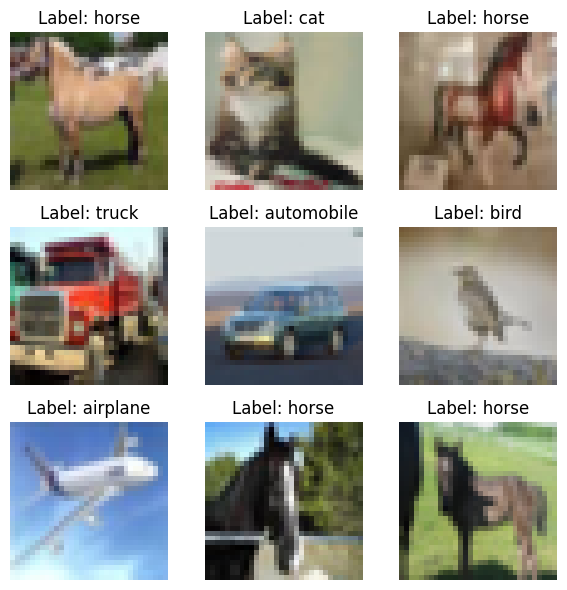

In [11]:
# 학습 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(trainloader)

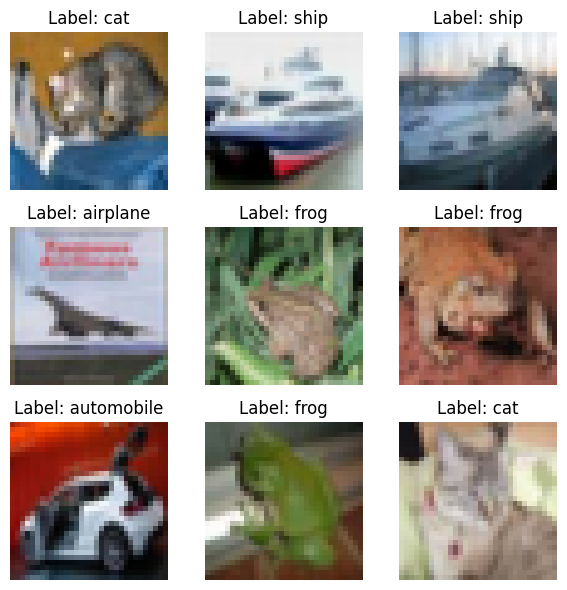

In [12]:
# 테스트 데이터셋에서 9개의 이미지를 시각화합니다.
show_multiple_images(testloader)

In [13]:
# function for building VGG Block

def build_vgg_block(input_layer,
                    num_cnn=3,
                    channel=64,
                    block_num=1):
    # 입력 레이어
    x = input_layer

    # CNN 레이어
    layers = []
    in_channels = x.size(1)
    for cnn_num in range(num_cnn):
        layers.append(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=channel,
                kernel_size=3,
                stride=1,
                padding=1,
            )
        )
        layers.append(nn.ReLU(inplace=True))
        in_channels = channel

    # Max Pooling 레이어
    layers.append(
        nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
    )

    # Sequential으로 레이어 묶기
    block = nn.Sequential(*layers)
    return block

In [14]:
class VGGNet(nn.Module):
    def __init__(self):
        super(VGGNet, self).__init__()

        # VGG 블록 생성
        self.vgg_block = build_vgg_block(torch.zeros(1, 3, 32, 32))
    def forward(self, x):
        return self.vgg_block(x)

In [15]:
# 블록 1개짜리 model 생성
model = VGGNet()
print(model)

dummy_input = torch.zeros(1, 3, 32, 32)
output = model(dummy_input)
print(output.shape)

VGGNet(
  (vgg_block): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)
torch.Size([1, 64, 16, 16])


In [16]:
BATCH_SIZE = 256
EPOCH = 15

In [17]:
# CIFAR-10 데이터셋에 대해 Normalize와 Tensor 변환을 적용하는 코드
transform = transforms.Compose([
    transforms.ToTensor(),  # 이미지를 Tensor로 변환
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # VGG-16 표준 정규화
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

In [18]:
import time

current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_16 = torchvision.models.vgg16(pretrained=True)
vgg_16.to(device)

for param in vgg_16.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_16.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_16_train_losses = []
vgg_16_val_accuracy = []

for epoch in range(EPOCH):
    vgg_16.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_16(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    train_acc = 100 * correct / total
    vgg_16_train_losses.append(train_loss)

    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_16.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_16(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_16_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

C:\Users\Owner\aiffel\work\AIFFEL_quest_rs\Exploration\Ex03\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Owner\aiffel\work\AIFFEL_quest_rs\Exploration\Ex03\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1,   100] loss: 3.944
Epoch 1: Train Accuracy: 42.24%
Epoch 1: Validation Accuracy: 69.28%
[2,   100] loss: 1.833
Epoch 2: Train Accuracy: 73.49%
Epoch 2: Validation Accuracy: 77.00%
[3,   100] loss: 1.617
Epoch 3: Train Accuracy: 79.96%
Epoch 3: Validation Accuracy: 80.57%
[4,   100] loss: 1.506
Epoch 4: Train Accuracy: 83.49%
Epoch 4: Validation Accuracy: 81.41%
[5,   100] loss: 1.425
Epoch 5: Train Accuracy: 85.75%
Epoch 5: Validation Accuracy: 83.55%
[6,   100] loss: 1.371
Epoch 6: Train Accuracy: 87.56%
Epoch 6: Validation Accuracy: 84.16%
[7,   100] loss: 1.316
Epoch 7: Train Accuracy: 89.38%
Epoch 7: Validation Accuracy: 84.70%
[8,   100] loss: 1.269
Epoch 8: Train Accuracy: 90.81%
Epoch 8: Validation Accuracy: 84.71%
[9,   100] loss: 1.229
Epoch 9: Train Accuracy: 92.10%
Epoch 9: Validation Accuracy: 84.90%
[10,   100] loss: 1.197
Epoch 10: Train Accuracy: 93.47%
Epoch 10: Validation Accuracy: 84.77%
[11,   100] loss: 1.170
Epoch 11: Train Accuracy: 94.50%
Epoch 11: Validation

In [19]:
current_time = time.time()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_19 = torchvision.models.vgg19(pretrained=True)
vgg_19.to(device)

for param in vgg_19.parameters():
    param.requires_grad = True
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_19.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)

vgg_19_train_losses = []
vgg_19_val_accuracy = []

for epoch in range(EPOCH):
    vgg_19.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader, 0):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vgg_19(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        if i % 100 == 99:
            print(f"[{epoch + 1}, {i + 1:5d}] loss: {running_loss / i + 1:.3f}")

    train_loss = running_loss / len(trainloader)
    vgg_19_train_losses.append(train_loss)

    train_acc = 100 * correct / total
    print(f"Epoch {epoch + 1}: Train Accuracy: {train_acc:.2f}%")

    vgg_19.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_19(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    vgg_19_val_accuracy.append(val_acc)

    print(f"Epoch {epoch + 1}: Validation Accuracy: {val_acc:.2f}%")

print("Finished Training")
print(time.time() - current_time)

C:\Users\Owner\aiffel\work\AIFFEL_quest_rs\Exploration\Ex03\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


[1,   100] loss: 3.733
Epoch 1: Train Accuracy: 43.02%
Epoch 1: Validation Accuracy: 70.03%
[2,   100] loss: 1.802
Epoch 2: Train Accuracy: 74.66%
Epoch 2: Validation Accuracy: 77.83%
[3,   100] loss: 1.585
Epoch 3: Train Accuracy: 80.90%
Epoch 3: Validation Accuracy: 82.06%
[4,   100] loss: 1.489
Epoch 4: Train Accuracy: 84.12%
Epoch 4: Validation Accuracy: 83.77%
[5,   100] loss: 1.422
Epoch 5: Train Accuracy: 86.40%
Epoch 5: Validation Accuracy: 84.59%
[6,   100] loss: 1.352
Epoch 6: Train Accuracy: 88.35%
Epoch 6: Validation Accuracy: 84.98%
[7,   100] loss: 1.301
Epoch 7: Train Accuracy: 89.65%
Epoch 7: Validation Accuracy: 85.08%
[8,   100] loss: 1.264
Epoch 8: Train Accuracy: 91.05%
Epoch 8: Validation Accuracy: 85.58%
[9,   100] loss: 1.231
Epoch 9: Train Accuracy: 92.36%
Epoch 9: Validation Accuracy: 86.28%
[10,   100] loss: 1.200
Epoch 10: Train Accuracy: 93.40%
Epoch 10: Validation Accuracy: 86.16%
[11,   100] loss: 1.163
Epoch 11: Train Accuracy: 94.56%
Epoch 11: Validation

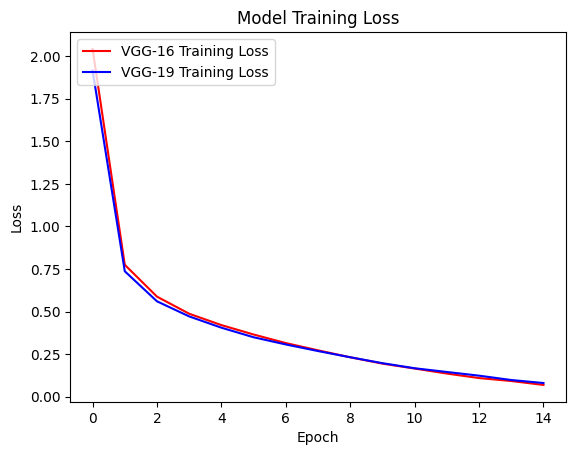

In [20]:
import matplotlib.pyplot as plt

plt.plot(vgg_16_train_losses, 'r', label="VGG-16 Training Loss")
plt.plot(vgg_19_train_losses, 'b', label="VGG-19 Training Loss")

plt.title('Model Training Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

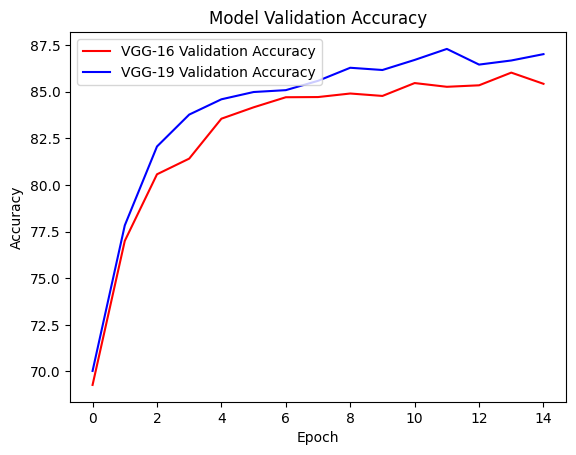

In [21]:
plt.plot(vgg_16_val_accuracy, 'r', label="VGG-16 Validation Accuracy")
plt.plot(vgg_19_val_accuracy, 'b', label="VGG-19 Validation Accuracy")

plt.title('Model Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

###ResNet 실습: 34와 50 각각 비교하기

1. ResNet-34: plain 모델과 residual 모델 비교

In [22]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [38]:
class BasicBlock(nn.Module):
    expansion = 1 # 출력 채널 배수 (BasicBlock은 입출력 채널이 같으므로 1)

    def __init__(self, in_planes, planes, stride=1, is_plain=False):
        super(BasicBlock, self).__init__()
        self.is_plain = is_plain # 잔차 연결을 제외할지 결정하는 플래그 (Ablation Study용)

        # 첫 번째 합성곱 레이어: 이미지의 특징을 추출
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes) # 학습을 안정화시키는 배치 정규화

        # 두 번째 합성곱 레이어: 추출된 특징을 한 번 더 처리
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # 숏컷(Shortcut): 입력 데이터 x를 출력에 더해주기 위한 경로
        self.shortcut = nn.Sequential()
        # 입력과 출력의 크기(이미지 가로세로 또는 채널 수)가 다를 경우 크기를 맞춰주는 작업
        if stride != 1 or in_planes != self.expansion*planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion*planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion*planes)
            )

    def forward(self, x):
        identity = x # 입력값 x를 나중에 더해주기 위해 별도로 보관 (잔차)

        # 레이어 통과: Conv1 -> BN1 -> ReLU 활성화 함수
        out = torch.relu(self.bn1(self.conv1(x)))
        # 레이어 통과: Conv2 -> BN2 (아직 ReLU는 통과하지 않음)
        out = self.bn2(self.conv2(out))

        # [Ablation Study 핵심] 잔차 연결 수행 여부 결정
        # is_plain이 False일 때만 입력값(identity)을 결과값(out)에 더함
        if not self.is_plain:
            out += self.shortcut(identity) # F(x) + x 연산 수행

        out = torch.relu(out) # 마지막 활성화 함수 통과
        return out

# 모델 생성 함수: ResNet-34 또는 Plain-34를 만듦
def build_resnet_34(is_plain=False, num_classes=37):
    # num_blocks=[3, 4, 6, 3]: 각 스테이지에 블록을 3개, 4개, 6개, 3개씩 쌓으라는 의미 (총 34층 내외)
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes=num_classes, is_plain=is_plain)

In [39]:
# ResNet 메인 클래스: 실제 신경망의 전체 구조를 설계합니다.
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=37, is_plain=False):
        super(ResNet, self).__init__()
        self.in_planes = 64
        self.is_plain = is_plain

        # [입력층] 7x7 합성곱 레이어
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # [은닉층] Residual Block들을 단계별로 쌓음
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # [출력층] 최종 분류 레이어
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s, self.is_plain))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        # 입력층 통과
        out = torch.relu(self.bn1(self.conv1(x)))
        out = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)(out)

        # 각 레이어 통과
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # 전역 평균 풀링 및 분류
        out = nn.AdaptiveAvgPool2d((1, 1))(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

In [40]:
transform = transforms.Compose([
    # 1. 이미지 크기 조절: 다양한 크기의 원본 이미지를 ResNet의 표준 입력 크기인 224x224로 맞춥니다.
    transforms.Resize((224, 224)),

    # 2. 텐서 변환: 일반 이미지 파일을 컴퓨터가 연산할 수 있는 숫자 행렬(Tensor)로 바꿉니다.
    # 이 과정에서 0~255 사이의 픽셀 값이 0~1 사이의 값으로 변환됩니다.
    transforms.ToTensor(),

    # 3. 정규화: 각 색상 채널(R, G, B)의 평균과 표준편차를 사용하여 데이터 분포를 맞춥니다.
    # (0.485, 0.456, 0.406)은 ImageNet 데이터셋의 평균값이며, 학습 속도를 높이고 안정화합니다.
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# 학습 및 검증용 데이터셋: 반려동물 37종의 이미지와 라벨을 가져옵니다.
train_dataset = datasets.OxfordIIITPet(
    root='./data',      # 데이터를 저장할 폴더 경로
    split='trainval',   # 학습(Train)과 검증(Validation)용 데이터를 가져옴
    download=True,      # 폴더에 데이터가 없으면 인터넷에서 자동으로 다운로드
    transform=transform # 위에서 만든 전처리 공정(Resize, Normalize 등)을 적용
)

# 테스트용 데이터셋: 모델의 최종 성능을 평가하기 위한 별도의 데이터를 가져옵니다.
test_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

# 학습 데이터 로더
train_loader = DataLoader(
    train_dataset,
    batch_size=32,   # 한 번에 32장씩 묶어서 GPU로 보냅니다. (RTX 5070 Ti라면 64~128도 가능합니다)
    shuffle=True     # 데이터를 섞어서 모델이 순서를 외우지 못하게 하고 학습 효율을 높입니다.
)

# 테스트 데이터 로더
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False    # 평가는 순서가 중요하지 않으며, 일관된 비교를 위해 섞지 않습니다.
)

In [41]:
def train_model(model, name, epochs=5):
    # --- [준비 단계] ---
    # GPU가 사용 가능한지 확인하고, 모델을 해당 장치(GPU 또는 CPU)로 보냅니다.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # 손실 함수(Criterion): 모델의 예측값과 실제 정답 사이의 오차를 계산합니다.
    # CrossEntropyLoss는 분류 문제에서 표준적으로 사용됩니다.
    criterion = nn.CrossEntropyLoss()

    # 최적화 도구(Optimizer): 계산된 오차를 바탕으로 모델의 가중치를 어떻게 수정할지 결정합니다.
    # SGD(확률적 경사하강법)에 관성(Momentum)을 더해 학습의 효율을 높였습니다.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    # 학습 과정을 기록할 주머니(History)를 만듭니다.
    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    # 지정한 에폭(전체 데이터 반복 횟수)만큼 반복합니다.
    for epoch in range(epochs):
        # --- [학습 단계: Training Phase] ---
        model.train() # 모델을 '학습 모드'로 설정 (드롭아웃, 배치 정규화 등이 활성화됨)
        running_loss, correct, total = 0.0, 0, 0

        # train_loader에서 묶음(Batch) 단위로 데이터를 꺼내옵니다.
        for inputs, labels in train_loader:
            # 데이터를 GPU(또는 CPU)로 전송합니다.
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. 기울기 초기화: 이전 배치에서 계산된 기울기를 지웁니다.
            optimizer.zero_grad()

            # 2. 순전파(Forward): 모델에 데이터를 넣어 예측값(outputs)을 뽑습니다.
            outputs = model(inputs)

            # 3. 손실 계산: 예측값과 실제 정답(labels) 사이의 오차를 구합니다.
            loss = criterion(outputs, labels)

            # 4. 역전파(Backward): 오차를 역으로 전파시켜 각 가중치가 오차에 기여한 정도(기울기)를 계산합니다.
            loss.backward()

            # 5. 가중치 업데이트: 계산된 기울기를 따라 모델의 가중치를 수정합니다.
            optimizer.step()

            # 통계 계산: 현재 배치의 손실과 맞힌 개수를 누적합니다.
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        # --- [검증 단계: Validation Phase] ---
        model.eval() # 모델을 '평가 모드'로 설정 (학습에만 필요한 기능들을 비활성화)
        v_correct, v_total = 0, 0

        # 검증 시에는 기울기를 계산할 필요가 없으므로 메모리와 연산량을 아낍니다.
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                v_total += labels.size(0)
                v_correct += predicted.eq(labels).sum().item()

        # --- [기록 및 출력] ---
        # 한 에폭이 끝날 때마다 평균 손실과 정확도를 계산하여 저장합니다.
        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(100 * correct / total)
        history['val_acc'].append(100 * v_correct / v_total)

        # 현재 학습 상태를 화면에 출력합니다.
        print(f"{name} Ep {epoch+1} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    # 모든 학습이 완료되면 기록된 history 객체를 반환합니다.
    return history

In [42]:
def summarize_results(plain_h, resnet_h, model_name="ResNet"):
    # 1. 그래프 시각화
    plt.figure(figsize=(14, 5))

    # Loss 비교
    plt.subplot(1, 2, 1)
    plt.plot(plain_h['train_loss'], 'r--', label=f'Plain-{model_name.split("-")[-1]} Loss')
    plt.plot(resnet_h['train_loss'], 'b-', label=f'{model_name} Loss')
    plt.title(f'Loss Comparison ({model_name})')
    plt.legend()

    # Accuracy 비교
    plt.subplot(1, 2, 2)
    plt.plot(plain_h['val_acc'], 'r--', label=f'Plain-{model_name.split("-")[-1]} Val Acc')
    plt.plot(resnet_h['val_acc'], 'b-', label=f'{model_name} Val Acc')
    plt.title(f'Validation Accuracy Comparison ({model_name})')
    plt.legend()
    plt.show()

    # 2. 테이블 시각화 (Pandas)
    data = {
        "Model": [f"Plain-{model_name.split('-')[-1]}", model_name],
        "Residual": ["Disabled", "Enabled"],
        "Final Loss": [f"{plain_h['train_loss'][-1]:.4f}", f"{resnet_h['train_loss'][-1]:.4f}"],
        "Best Val Acc": [f"{max(plain_h['val_acc']):.2f}%", f"{max(resnet_h['val_acc']):.2f}%"]
    }
    df = pd.DataFrame(data)
    print("\n" + "="*60)
    print(f"      [ Ablation Study: {model_name} vs Plain Summary ]")
    print("="*60)
    print(df.to_string(index=False))
    print("="*60)

In [43]:
import matplotlib.pyplot as plt

def plot_comparison(h1, h2, title):
    plt.figure(figsize=(12, 5))

    # Loss 비교
    plt.subplot(1, 2, 1)
    plt.plot(h1['loss'], label='Plain-34')
    plt.plot(h2['loss'], label='ResNet-34')
    plt.title(f'{title} - Loss')
    plt.legend()

    # Accuracy 비교
    plt.subplot(1, 2, 2)
    plt.plot(h1['acc'], label='Plain-34')
    plt.plot(h2['acc'], label='ResNet-34')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.show()

Plain-34 Ep 1 | Loss: 3.6797 | Val Acc: 3.49%
Plain-34 Ep 2 | Loss: 3.6043 | Val Acc: 4.50%
Plain-34 Ep 3 | Loss: 3.5385 | Val Acc: 4.39%
Plain-34 Ep 4 | Loss: 3.4715 | Val Acc: 4.33%
Plain-34 Ep 5 | Loss: 3.4274 | Val Acc: 5.21%
ResNet-34 Ep 1 | Loss: 3.8831 | Val Acc: 4.85%
ResNet-34 Ep 2 | Loss: 3.5255 | Val Acc: 6.16%
ResNet-34 Ep 3 | Loss: 3.3549 | Val Acc: 9.13%
ResNet-34 Ep 4 | Loss: 3.1918 | Val Acc: 11.39%
ResNet-34 Ep 5 | Loss: 3.0333 | Val Acc: 13.95%


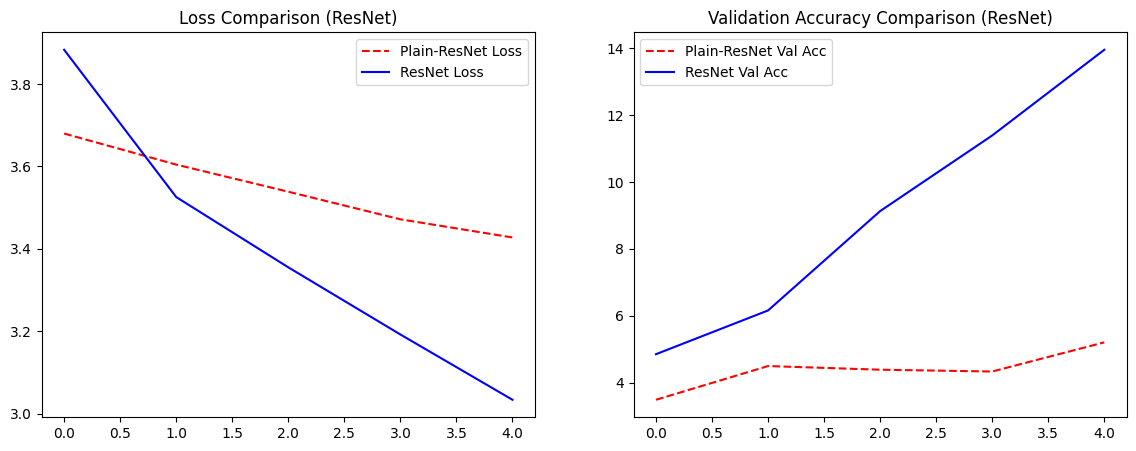


      [ Ablation Study: ResNet vs Plain Summary ]
       Model Residual Final Loss Best Val Acc
Plain-ResNet Disabled     3.4274        5.21%
      ResNet  Enabled     3.0333       13.95%


In [44]:
# [Ablation Study 실행 1] 잔차 연결(Shortcut)이 제거된 'Plain-34' 모델을 학습시킵니다.
# 1. build_resnet_34(is_plain=True): 34층의 깊이를 가지지만 지름길이 없는 '평면(Plain)' 모델을 생성합니다.
# 2. train_model(..., "Plain-34", epochs=5): 생성된 모델을 5회 반복 학습시키고 그 기록을 변수에 저장합니다.
plain_34_history = train_model(build_resnet_34(is_plain=True), "Plain-34", epochs=5)

# [Ablation Study 실행 2] 잔차 연결이 포함된 오리지널 'ResNet-34' 모델을 학습시킵니다.
# 1. build_resnet_34(is_plain=False): ResNet의 핵심인 $F(x) + x$ 연산(Shortcut)이 활성화된 모델을 생성합니다.
# 2. train_model(..., "ResNet-34", epochs=5): 동일한 조건에서 5회 반복 학습을 진행합니다.
resnet_34_history = train_model(build_resnet_34(is_plain=False), "ResNet-34", epochs=5)

# [5] 최종 결과 출력 및 비교 시각화
# 두 모델의 학습 기록(Loss, Accuracy)이 담긴 객체들을 비교 함수에 전달합니다.
# 이 함수는 두 모델의 성능 차이를 한눈에 볼 수 있는 '그래프'와 '요약 테이블'을 화면에 띄웁니다.
summarize_results(plain_34_history, resnet_34_history)

ResNet-34에서 잔차 연결(Residual Connection)이 학습에 미치는 영향: Ablation Study

본 테스트는 ResNet-34에서 잔차 연결이 학습에 미치는 영향을 알아보고자 기존의 plain 모델과 residual 모델 간의 5회 epoch을 실시한 바탕으로 비교를 진행하였고, 짧은 학습 임에도 불구하고 두 모델 간에 유의미한 결과를 확인할 수 있다.

**Loss comparison:** plain 모델의 경우 손실값이 매우 완만하게 감소한다. 이는 네트워크가 깊어짐에 따라 발생하는 경사 소실(Gradient Vanishing) 문제로 인해 학습 효율이 떨어지고 있음을 시사한다. 반면 residual 모델의 경우 초기 1에폭 이후 손실값이 급격하게 떨어지는 가파른 곡선을 그린다. 잔차 연결이 정보의 흐름을 원활하게 하여 최적화(Optimization)를 돕고 있다는 것을 시사한다.

**Validation Accuracy comparison:** Plain 모델의 경우 2에폭까지 오히려 정확도가 떨어지다 마지막에 겨우 반등하는 등 불안정한 모습을 보이는 반면 Residual 모델은 기복은 있지만 전체적으로 꾸준히 우상향하는 추세를 보인다.

2. ResNet-50: plain 모델과 residual 모델 간의 비교

In [30]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_planes, planes, stride=1, is_plain=False):
        super(Bottleneck, self).__init__()
        self.is_plain = is_plain

        # 1x1 conv (채널 압축)
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)

        # 3x3 conv (특징 추출)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        # 1x1 conv (채널 확장)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.expansion * planes)

        # Shortcut 연결: 입력과 출력의 크기가 다를 때 맞춰주는 역할
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    # 이 부분이 빠졌거나 이름이 틀리면 NotImplementedError가 납니다!
    def forward(self, x):
        identity = x

        out = torch.relu(self.bn1(self.conv1(x)))
        out = torch.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))

        # Ablation Study: is_plain이 False일 때만 Shortcut(잔차) 연결
        if not self.is_plain:
            out += self.shortcut(identity)

        out = torch.relu(out)
        return out

In [31]:
# ResNet-50 메인 클래스 정의
class ResNet50(nn.Module):
    def __init__(self, block, num_blocks, num_classes=37, is_plain=False):
        super(ResNet50, self).__init__()
        self.in_planes = 64
        self.is_plain = is_plain

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # ResNet-50 블록 구성: [3, 4, 6, 3]
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s, self.is_plain))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

In [32]:
def train_model(model, name, train_loader, test_loader, epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = outputs.max(1)
                v_total += labels.size(0)
                v_correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(running_loss / len(train_loader))
        history['train_acc'].append(100 * correct / total)
        history['val_acc'].append(100 * v_correct / v_total)

        print(f"{name} Ep {epoch+1} | Loss: {history['train_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [33]:
if __name__ == "__main__":
    # 데이터 준비
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    train_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform)
    test_dataset = datasets.OxfordIIITPet(root='./data', split='test', download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    # 모델 생성 (Plain vs Residual)
    plain_50 = ResNet50(Bottleneck, [3, 4, 6, 3], is_plain=True)
    resnet_50 = ResNet50(Bottleneck, [3, 4, 6, 3], is_plain=False)

Plain-50 Ep 1 | Loss: 3.7481 | Val Acc: 2.78%
Plain-50 Ep 2 | Loss: 3.6332 | Val Acc: 3.27%
Plain-50 Ep 3 | Loss: 3.6055 | Val Acc: 3.22%
Plain-50 Ep 4 | Loss: 3.5816 | Val Acc: 3.87%
Plain-50 Ep 5 | Loss: 3.5441 | Val Acc: 5.01%
ResNet-50 Ep 1 | Loss: 4.0845 | Val Acc: 3.03%
ResNet-50 Ep 2 | Loss: 3.6162 | Val Acc: 5.01%
ResNet-50 Ep 3 | Loss: 3.4852 | Val Acc: 6.49%
ResNet-50 Ep 4 | Loss: 3.4464 | Val Acc: 8.09%
ResNet-50 Ep 5 | Loss: 3.3462 | Val Acc: 9.13%


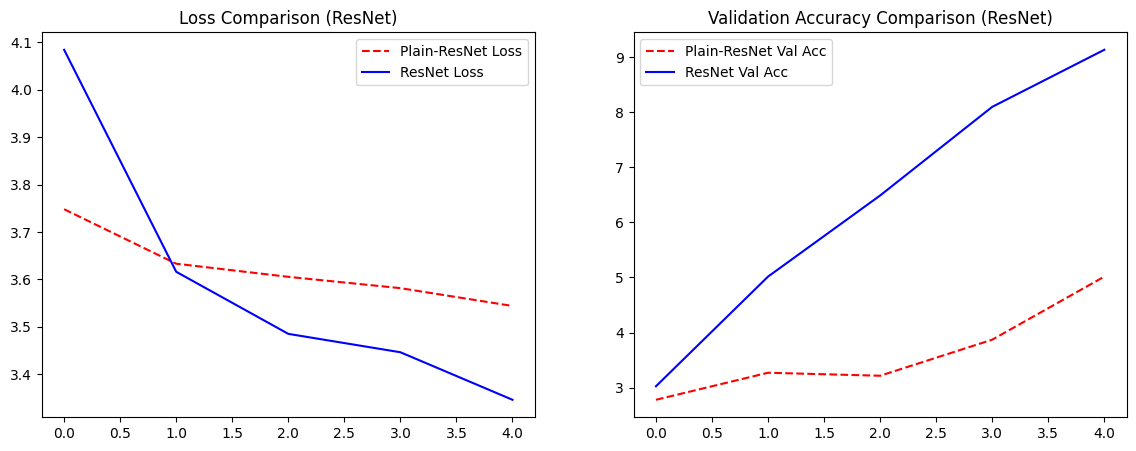


      [ Ablation Study: ResNet vs Plain Summary ]
       Model Residual Final Loss Best Val Acc
Plain-ResNet Disabled     3.5441        5.01%
      ResNet  Enabled     3.3462        9.13%


In [34]:
# 학습 진행
plain_50_history = train_model(plain_50, "Plain-50", train_loader, test_loader, epochs=5)
resnet_50_history = train_model(resnet_50, "ResNet-50", train_loader, test_loader, epochs=5)

# 결과 출력
summarize_results(plain_50_history, resnet_50_history)

Residual-50에서 잔차 연결(Residual connection)이 학습에 미치는 영향: Alation Study

본 테스트는 ResNet-34에서 잔차 연결이 학습에 미치는 영향을 알아보고자 기존의 plain 모델과 residual 모델 간의 5회 epoch을 실시한 바탕으로 비교를 진행하였고, 짧은 학습 임에도 불구하고 두 모델 간에 유의미한 결과를 확인할 수 있다.

Loss comparison: Plain)은 손실값이 매우 완만하게 줄어든다. 이는 레이어가 깊어지면서 기울기 정보가 사라지는 경사 소실(Vanishing Gradient) 문제로 인해 모델이 데이터를 제대로 학습하지 못하고 있음을 나타낸다. 반면 Residual 모델의 경우 초기 손실값이 Plain보다 높게 시작함에도 불구하고, 1~2 에폭만에 훨씬 더 가파르게 하강한다. 이는 잔차 연결이 최적화(Optimization)를 훨씬 수월하게 만들어 준다는 것을 의미한다.

Accuracy Validation comparison: 정확도 또한 Residual 모델이 Plain 모델보다 확연히 우세한 성능을 보이고 있다. 하지만 흥미로운 결과를 확인할 수 있는데 이는 본 테스트의 짧은 학습(5에폭)에서는 34 레이어 Residual 모델이 50 레이어 Residual 모델보다 높은 성능을 보이고 있다는 점이다. 이는 레이어가 더 깊은 50층 모델은 학습해야 할 파라미터가 훨씬 많기 때문에, 동일한 데이터셋에서 수렴하기까지 더 많은 학습 시간(Epoch)이 필요하기 때문으로 생각된다.